# TS2: Modelizando un ADC

## Introducción

En este trabajo se simula el bloque de cuantización de un ADC de B bits, en un rango de -VF y +VF Volts, muestreando a fs Hz.
Se digitaliza una señal senoidal contaminada con un nivel de ruido analógico predeterminado. El modelo utilizado es S_R = xx + n, donde xx es la senoidal limpia y n es el ruido analógico, con potencia P_n = k_n · P_q, siendo P_q = q²/12 la potencia teórica del ruido de cuantización y q el paso de cuantización del ADC.
Se analiza el caso base (B=4 bits, k_n=1) y luego se compara el comportamiento del sistema para distintas combinaciones de B y k_n.

### Parámetros generales e imports y genero senoidal

In [4]:
#importo modulos
import numpy as np
import matplotlib.pyplot as plt

N = 1000
fs = 1000
VF = 2
dc = 0
ph = 0
P = 1
vmax = np.sqrt(2*P)
f0 = fs/N 


def mi_funcion_sen(vmax, dc, frecuencia, ph, N, fs):
    nn = np.arange(0, N) / fs
    xx = dc + vmax*np.sin(2 * np.pi * frecuencia * nn + ph)
    return (nn, xx)

### Inciso A: B=4 bits, kn=1

Se simula un ADC de B=4 bits, con rango +/-VF=2V, digitalizando una senoidal de potencia normalizada de P=1W contaminada con ruido analógico gaussiano.
El factor kn=1 significa que la potencia del ruido analógico (P_n) es igual a la potencia del ruido de cuantización (P_q). Este es el caso "ideal" ya que no se desperdicia electrónica analógica de la que el ADC puede aprovechar, ni se desperdician bits del ADC resolviendo ruido que ya traía la señal.

Se calculó el paso de cuantización, la potencia teórica del ruido de cuantización, la potencia del ruido analógico a agregar y se generó la señal completa.

In [6]:
B = 4
kn = 1
q = (2*VF) / 2**B #paso de cuantizacion
Pq = q**2 / 12 #potencia teorica del ruido de cuantizacion (q^2/12)
Pn = kn * Pq  #potencia del ruido analogico

#genero la senoidal limpia
nn, xx = mi_funcion_sen(vmax, dc, f0, ph, N, fs)

#genero el ruido analogico
n = np.random.normal(0, np.sqrt(Pn), N)

#señal que entra al ADC
s_R = xx + n

#cuantizacion, redondeo cada muestra al escalon mas cercano de tamaño q
s_Q = q * np.round(s_R/q)
n_Q = s_Q - s_R # error de cuantizacion 

### Gráfico 1: dominio del tiempo

Se muestran juntas las tres señales para ver cómo actúa el ADC: la senoidal original (s), lo que efectivamente entra al conversor con el ruido ya sumado (s_R), y el resultado final después de cuantizar (s_Q), donde se nota el efecto de "escalón" propio de la cuantización.

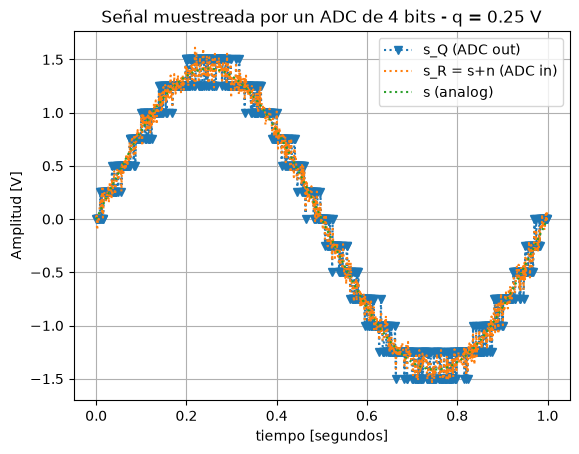

In [7]:
#señal en el dominio del tiempo
plt.figure()
plt.plot(nn, s_Q, ':v', label='s_Q (ADC out)')
plt.plot(nn, s_R, ':', label='s_R = s+n (ADC in)')
plt.plot(nn, xx, ':', label='s (analog)')
plt.title(f"Señal muestreada por un ADC de {B} bits - q = {q} V")
plt.xlabel("tiempo [segundos]")
plt.ylabel("Amplitud [V]")
plt.legend()
plt.grid()
plt.show()

### Gráfico 2: espectro de la señal cuantizada

Se calcula el espectro de s_Q junto con los "pisos" de ruido, el valor medio del espectro del ruido analógico y del ruido de cuantización. Con kn=1 se espera que ambos pisos queden prácticamente al mismo nivel, ya que ambos ruidos tienen la misma potencia.

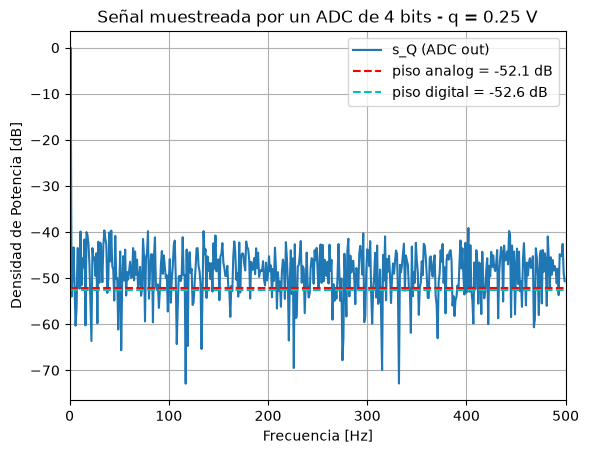

In [8]:
#eje de frecuencias
ff_vec = np.fft.fftfreq(N, 1/fs)

#espectro de s_Q, la señal cuantizada
XXQ = np.fft.fft(s_Q)
XXQ_mod = np.abs(XXQ[:N//2]) * 2/N
PQ_db = 10*np.log10(XXQ_mod**2 / 2 + 1e-12)

#espectro de ruido analogico, lo uso para sacar el piso
RR = np.fft.fft(n)
RR_mod = np.abs(RR[:N//2]) * 2/N
PR_db = 10*np.log10(RR_mod**2 / 2 + 1e-12)

#espectro de n_Q
NQ = np.fft.fft(n_Q)
NQ_mod = np.abs(NQ[:N//2]) * 2/N
PNQ_db = 10*np.log10(NQ_mod**2 / 2 + 1e-12)

#piso de ruido, salteo la muestra 0
piso_an = np.mean(PR_db[1:])
piso_dig = np.mean(PNQ_db[1:])

#no grafico s ni s_R porque se pisan con s_Q y no aportan nada
plt.figure()
plt.plot(ff_vec[:N//2], PQ_db, label='s_Q (ADC out)')
plt.axhline(piso_an, color='r', linestyle='--', label=f'piso analog = {piso_an:.1f} dB')
plt.axhline(piso_dig, color='c', linestyle='--', label=f'piso digital = {piso_dig:.1f} dB')
plt.title(f"Señal muestreada por un ADC de {B} bits - q = {q} V")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Densidad de Potencia [dB]")
plt.xlim(0, fs/2)
plt.legend()
plt.grid()
plt.show()

### Gráfico 3: histograma del error de cuantización

Se compara la distribución empírica del error de cuantización (n_Q) contra la densidad uniforme teórica, que debería tener una altura de 1/q entre -q/2 y +q/2.

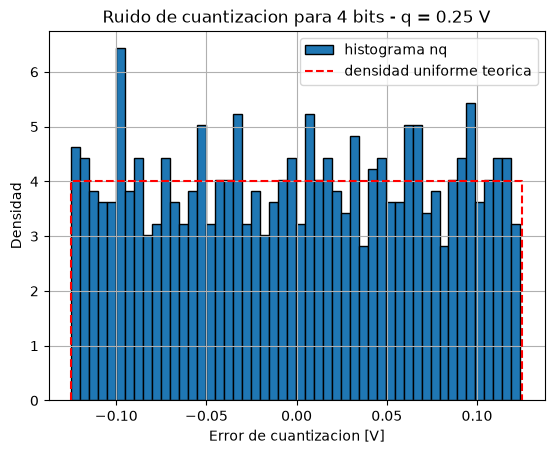

In [9]:
#histograma del error de cuantizacion
plt.figure()
plt.hist(n_Q, bins=50, density=True, color='tab:blue', edgecolor='black', label='histograma nq')
plt.plot([-q/2, -q/2, q/2, q/2], [0, 1/q, 1/q, 0], 'r--', label='densidad uniforme teorica')
plt.title(f"Ruido de cuantizacion para {B} bits - q = {q} V")
plt.xlabel("Error de cuantizacion [V]")
plt.ylabel("Densidad")
plt.legend()
plt.grid()
plt.show()

## Inciso B: B={4,8,16} bits, kn={1/10,1,10}

Se repite el experimento del inciso A para las 9 combinaciones posibles de B (4, 8, 16) bits y kn (1/10, 1, 10), para observar cómo cambia el comportamiento del sistema según la resolución del ADC y el balance entre el ruido analógico y el de cuantización.

Para cada combinación se muestran juntos: la señal en el dominio del tiempo, el espectro de la señal cuantizada con los pisos de ruido analógico y digital, y el histograma del error de cuantización comparado contra la densidad uniforme teórica.

In [10]:
# armo una funcion que repite todo el proceso de arriba, para no copiar y pegar el bloque 9 veces.
def simular_adc(B, kn):

    q = (2*VF) / 2**B
    Pq = q**2 / 12
    Pn = kn * Pq

    nn, xx = mi_funcion_sen(vmax, dc, f0, ph, N, fs)
    n = np.random.normal(0, np.sqrt(Pn), N)
    s_R = xx + n
    s_Q = q * np.round(s_R/q)
    n_Q = s_Q - s_R

    XXQ = np.fft.fft(s_Q)
    XXQ_mod = np.abs(XXQ[:N//2]) * 2/N
    PQ_db = 10*np.log10(XXQ_mod**2 / 2 + 1e-12)

    RR = np.fft.fft(n)
    RR_mod = np.abs(RR[:N//2]) * 2/N
    PR_db = 10*np.log10(RR_mod**2 / 2 + 1e-12)

    NQ = np.fft.fft(n_Q)
    NQ_mod = np.abs(NQ[:N//2]) * 2/N
    PNQ_db = 10*np.log10(NQ_mod**2 / 2 + 1e-12)

    piso_an = np.mean(PR_db[1:])
    piso_dig = np.mean(PNQ_db[1:])

    return nn, xx, s_R, s_Q, n_Q, q, PQ_db, piso_an, piso_dig

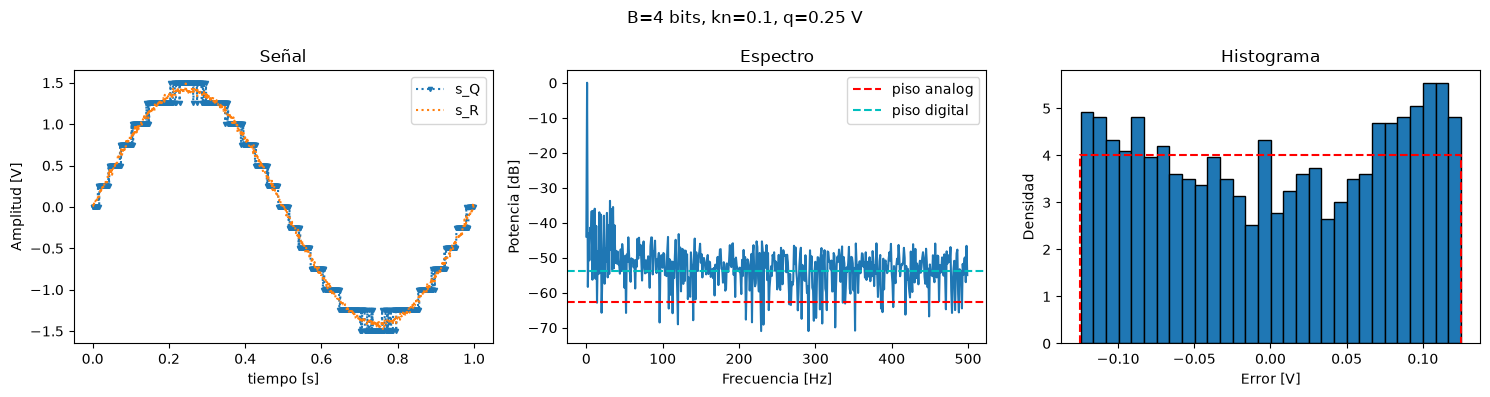

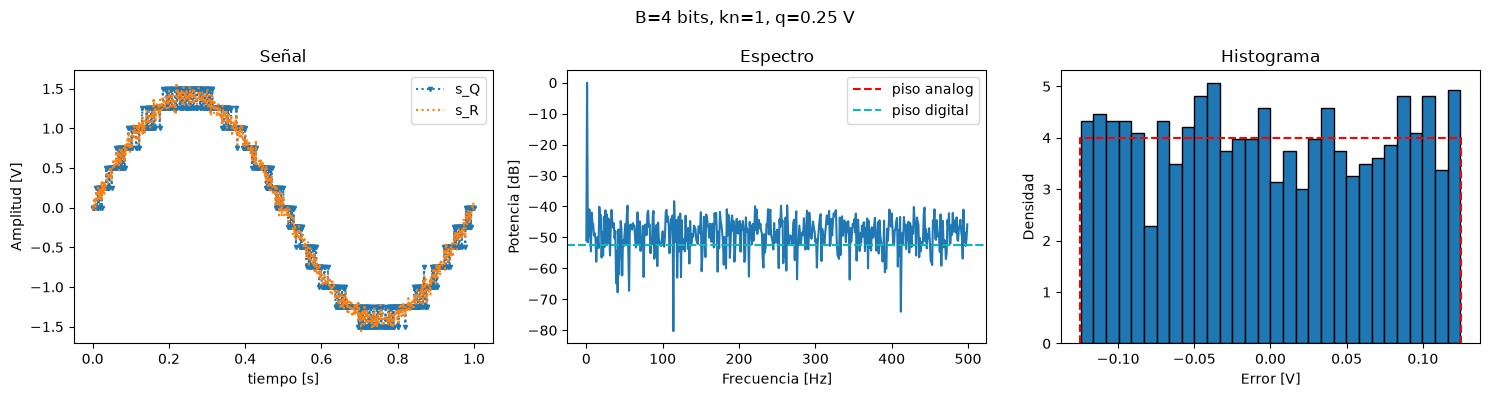

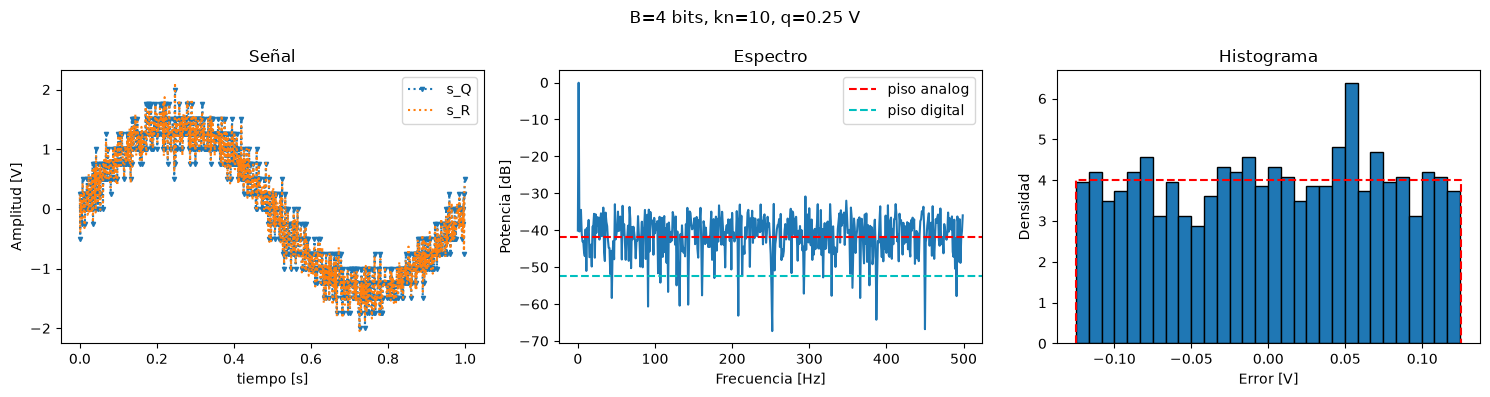

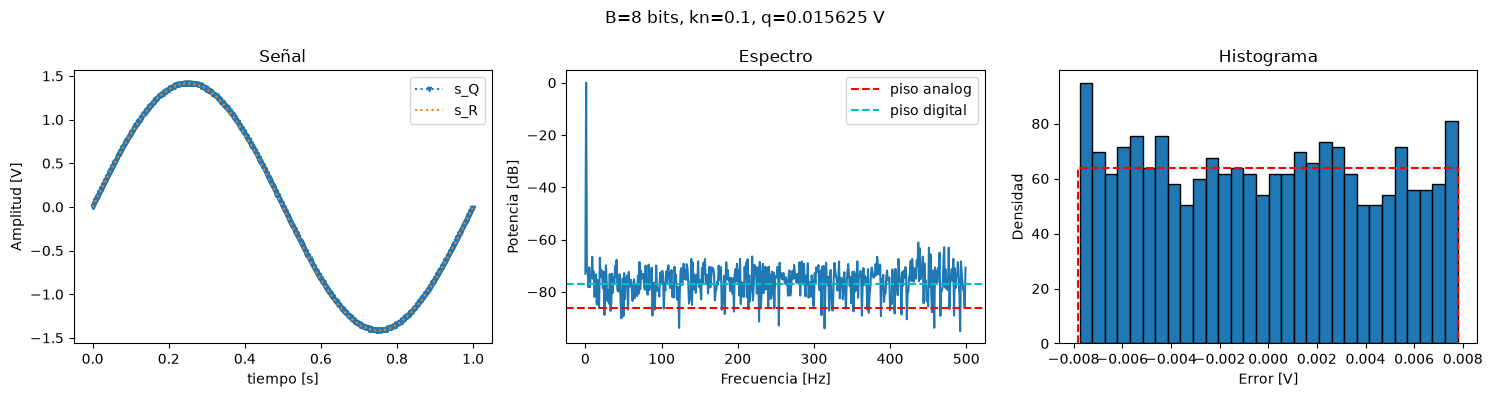

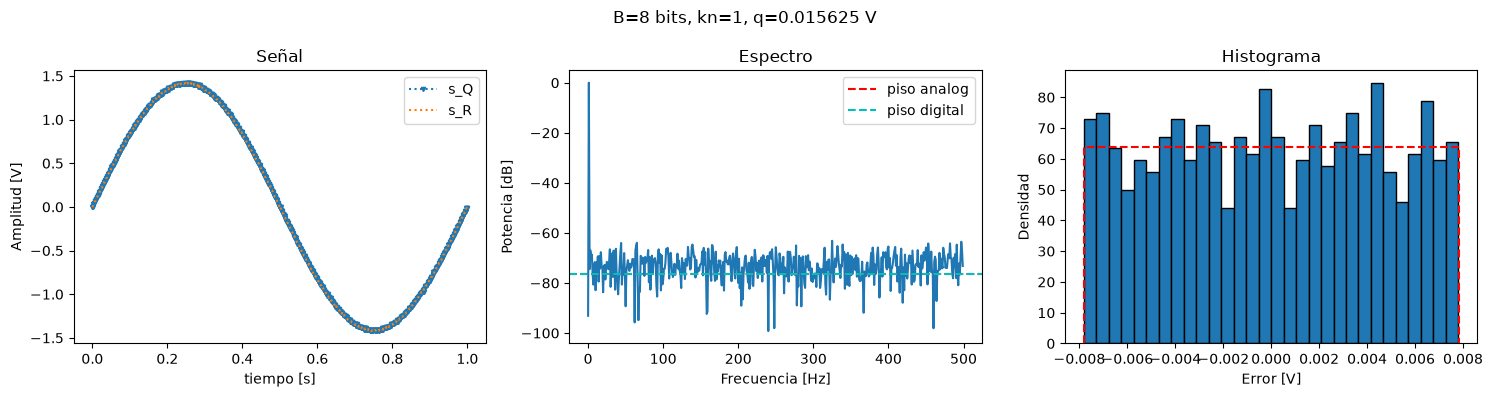

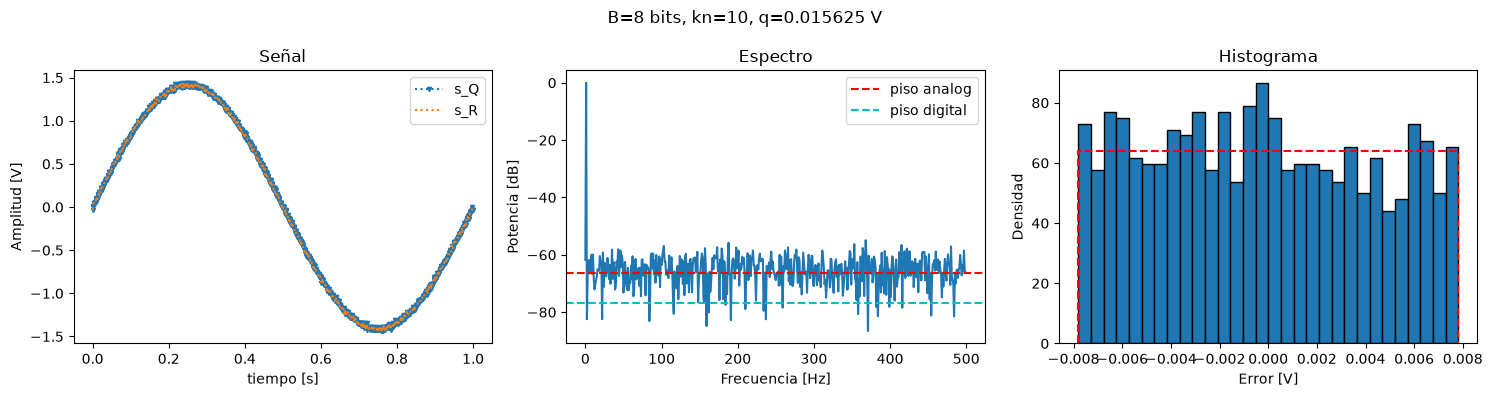

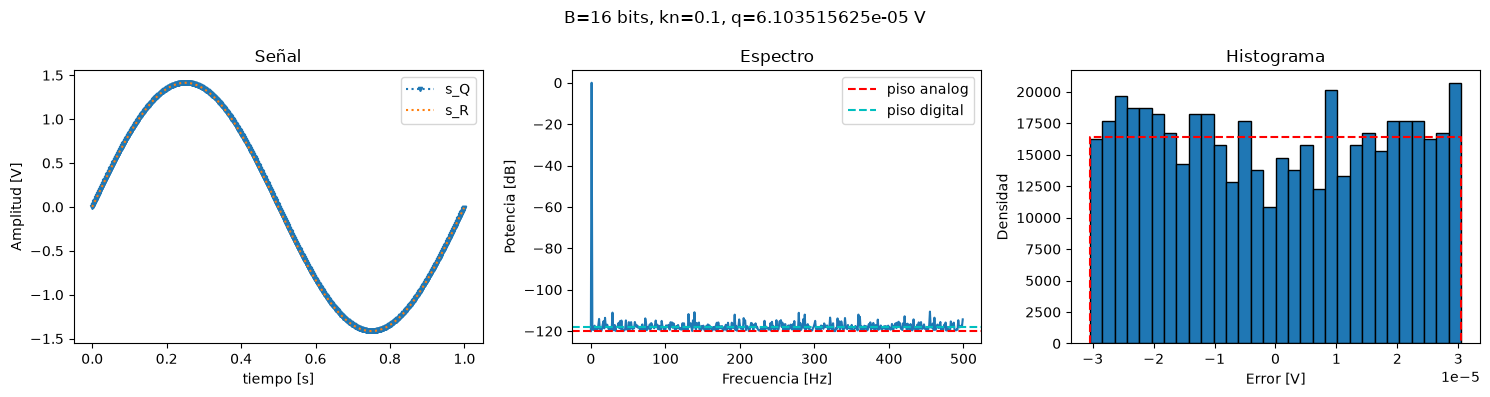

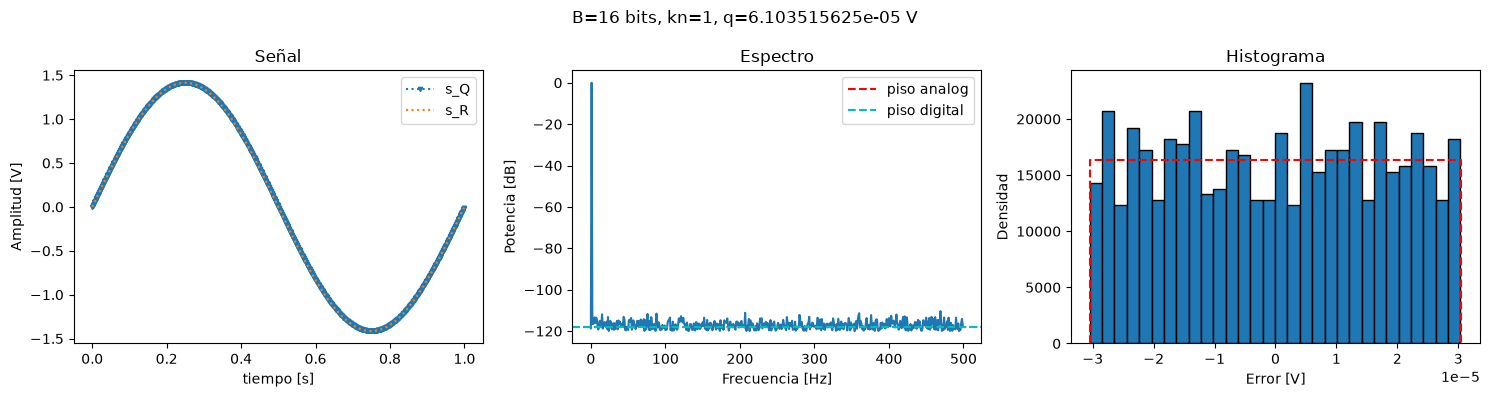

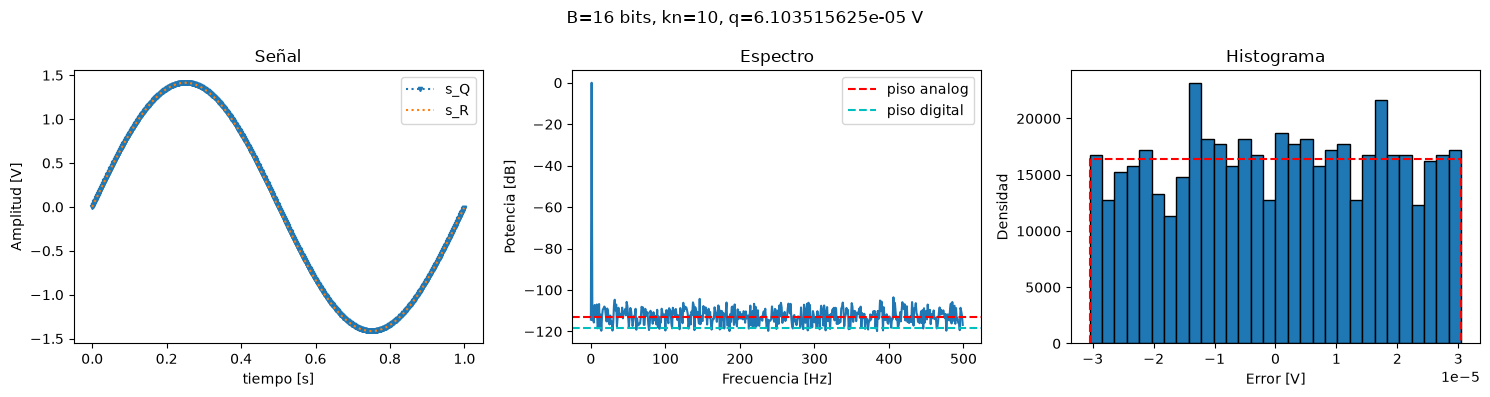

In [11]:
Bs = [4, 8, 16]
kns = [1/10, 1, 10]

for B in Bs:
    for kn in kns:

        nn, xx, s_R, s_Q, n_Q, q, PQ_db, piso_an, piso_dig = simular_adc(B, kn)
        
        plt.figure(figsize=(15, 4))

        #subplot 1: señal en el dominio del tiempo
        plt.subplot(1, 3, 1)
        plt.plot(nn, s_Q, ':v', markersize=3, label='s_Q')
        plt.plot(nn, s_R, ':', label='s_R')
        plt.title("Señal")
        plt.xlabel("tiempo [s]")
        plt.ylabel("Amplitud [V]")
        plt.legend()

        #subplot 2: espectro
        plt.subplot(1, 3, 2)
        plt.plot(ff_vec[:N//2], PQ_db)
        plt.axhline(piso_an, color='r', linestyle='--', label='piso analog')
        plt.axhline(piso_dig, color='c', linestyle='--', label='piso digital')
        plt.title("Espectro")
        plt.xlabel("Frecuencia [Hz]")
        plt.ylabel("Potencia [dB]")
        plt.legend()

        #subplot 3: histograma
        plt.subplot(1, 3, 3)
        plt.hist(n_Q, bins=30, density=True, color='tab:blue', edgecolor='black')
        plt.plot([-q/2, -q/2, q/2, q/2], [0, 1/q, 1/q, 0], 'r--')
        plt.title("Histograma")
        plt.xlabel("Error [V]")
        plt.ylabel("Densidad")

        plt.suptitle(f"B={B} bits, kn={kn}, q={q} V")
        plt.tight_layout()
        plt.show()

Se observa que, para cada valor de B, el comportamiento se repite de forma consistente al variar kn con kn=1/10 domina el ruido de cuantización, el piso digital queda por encima del analógico, con kn=1 ambos pisos quedan prácticamente al mismo nivel, y con kn=10 domina el ruido analógico, el piso analógico queda por encima.

Al aumentar B, el paso de cuantización q se hace más chico, y en consecuencia bajan tanto el nivel de los pisos de ruido como la escala del histograma del error de cuantización.pero indepentdientepente de la cantidad de bits, se sigue cumpleindo que el ruido domina según kn.

Esto confirma lo discutido en la clase,con kn=1 es la condición de diseño "ideal" ya que no se desperdicia electrónica analógica de la que el ADC aprovecha, ni se desperdician bits del ADC, y esta condición es válida sin importar la resolución del conversor.

## Conclusión

Este trabajo permitió entender de forma práctica qué pasa cuando una señal analógica, contaminada con ruido, pasa por un ADC.

Por un lado, vimos que la cuantización en sí misma genera un error inevitable que es el ruido de cuantización, cuya potencia teórica es P_q = (q^2)/12, y que efectivamente se distribuye de forma uniforme.

Por otro lado, y esta es la conclusión que me llevo del trabajo, idealmente siempre conviene diseñar el sistema para que kn=1, o que sea lo mas cercano a eso posible, es decir, que la potencia del ruido analógico sea igual a la potencia del ruido de cuantización. En ese punto, los dos "pisos" de ruido quedan prácticamente al mismo nivel, y no se desperdicia ni electrónica analógica de más calidad de la que el ADC puede aprovechar, ni bits del ADC resolviendo un ruido que la señal ya traía de antes.

Lo interesante es que esta condición de diseño ideal es válida independientemente de la cantidad de bits del ADC, ya que repetimos el mismo patrón para B=4, B=8 y B=16. Esto muestra que tener muchos bits no garantiza por sí solo un buen sistema, si el ruido analógico no está bien balanceado respecto al de cuantización, se puede tener un ADC de alta resolución funcionando de forma ineficiente.